# Приближение производной

Функция, которую будем приближать и дифференцировать:

$$f(x) = \text{sin} x \cdot \text{cos} x$$

$$f'(x) = \text{cos}^2 x - \text{sin}^2 x$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return np.sin(x)*np.cos(x)

def d(x):
    return np.cos(x)**2 - np.sin(x)**2

### Приближение справа 

$f(x) = Q_1(x) + R_1(x)$

$f'(x_k) = \frac{f(x_{k+1}) - f(x_{k})}{x_{k+1} - x_k}$

$f'(x) = Q_1'(x) + R_1'(x)$

Возьмем одинаковое расстояние $h$ между точками

Приближение $f'$ _справа_ в точке $x_k$: $\quad Q'_1(x) = \frac{y_{k+1} - y_{k}}{x_{k+1} - x_k} = \frac{y_{k+1} - y_{k}}{h}, \qquad y_i = f(x_i)$

Ошибка _cправа_ в точке $x_k$: $\quad \varepsilon(x_k) =  -\frac{(x_{k+1} - x_k)}{2} \cdot f''(\eta(x)) = -\frac{h}{2} \cdot f''(\eta(x)), \qquad x \in [x_k, x_{k+1}]$

Пусть $Q'_{(1)}, \: Q'_{(2)}$ - два интерполяционных полинома с шагами $h_{(1)}, \: h_{(2)}$ соответственно

Обозначим $C \approx f''(\eta(x))$, тогда ошибка $\varepsilon = -\frac{h}{2} \: C$ 

$$Q'_{(1)}  -C \: \frac{h_{(1)}}{2} \approx Q'_{(2)} -C \: \frac{h_{(2)}}{2}$$

$$C \approx 2 \cdot \frac{Q'_{(2)} - Q'_{(1)}}{h_{(2)} - h_{(1)}}$$

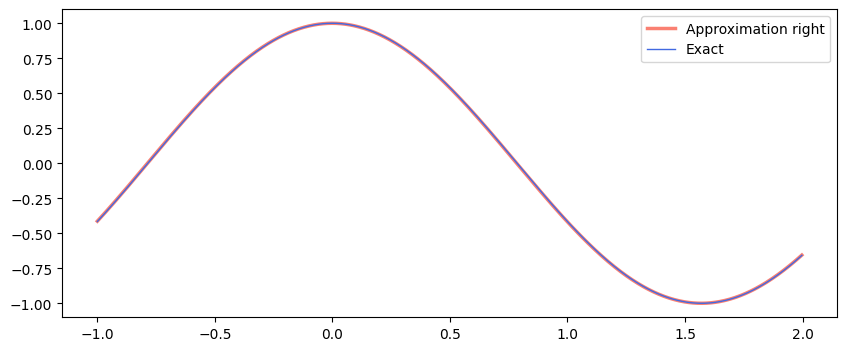

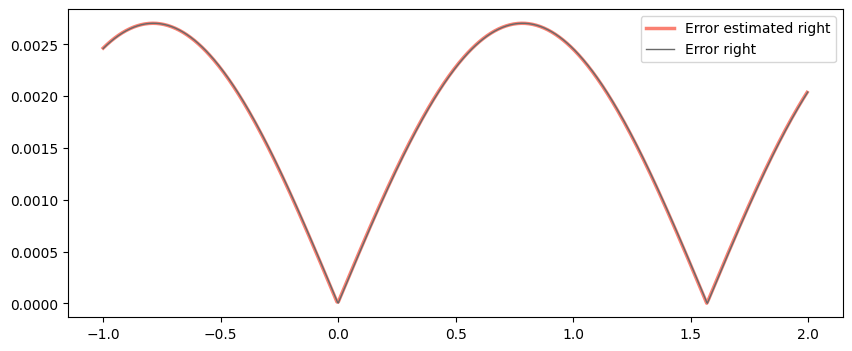

In [21]:
N = 1111
a, b = -1, 2
h = (b - a) / (N - 1) 

xx = np.linspace(a, b, N)
ff = f(xx) # значени функции f
dd = d(xx) # значения производной f

dright = (ff[1:] - ff[:-1]) / h  # вычислим для всех узлов, кроме последнего
err = np.abs(dd[:-1] - dright) # фактическая ошибка 

dright_2 = (ff[::2][1:] - ff[::2][:-1]) / (2*h)  # аппроксимация по сетке с шагом 2h
C = 2*(dright_2 - dright[::2])/(2*h - h) 
err_est = np.abs(-h/2 * C) # оценка ошибки 


plt.figure(figsize=(10, 4))
plt.plot(xx[:-1], dright, color = 'salmon', label = 'Approximation right', linewidth=2.5)
plt.plot(xx[:-1], dd[:-1], color = 'royalblue', label = 'Exact', linewidth=1)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(xx[::2][:-1], err_est, color = 'salmon',label = 'Error estimated right', linewidth=2.5)
plt.plot(xx[:-1], err, color = 'dimgrey', label = 'Error right', linewidth=1)
plt.legend()
plt.show()